In [26]:
from itertools import groupby
from operator import index
from textwrap import indent

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from seaborn import barplot
from seaborn._marks import bar

In [27]:
asn=pd.read_csv(r"C:\Users\Udayan Care\Desktop\RAHUL SONTAKKE\calude\Ecommerce.csv")
asn.head()

,OrderID,OrderDate,CustomerID,Gender,Age,City,State,Category,Product,Quantity,UnitPrice,DiscountPercent,ShippingCost,NetRevenue,PaymentMethod,OrderStatus,Rating
0,ORD107007,1/1/2024,CUST02988,Female,25,Hyderabad,Telangana,Electronics,Power Bank,2,1370.99,20,0.0,2193.58,Debit Card,Delivered,5.0
1,ORD102604,1/1/2024,CUST00580,Female,27,Hyderabad,Telangana,Fashion,Men's T-Shirt,1,1083.94,15,40.0,961.35,Cash on Delivery,Delivered,5.0
2,ORD107795,1/1/2024,CUST00500,Female,57,Lucknow,Uttar Pradesh,Electronics,Power Bank,2,998.51,0,40.0,2037.02,Net Banking,Delivered,3.0
3,ORD104129,1/1/2024,CUST02993,Male,42,Ahmedabad,Gujarat,Electronics,Laptop,1,82563.50,10,0.0,74307.15,Debit Card,Delivered,1.0
4,ORD108506,1/1/2024,CUST02568,Female,32,Delhi,Delhi,Electronics,Power Bank,1,2040.31,0,0.0,2040.31,Cash on Delivery,Delivered,3.0


In [28]:
asn.shape

(9000, 17)

In [29]:
asn.info()

<class 'pandas.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          9000 non-null   str    
 1   OrderDate        9000 non-null   str    
 2   CustomerID       9000 non-null   str    
 3   Gender           9000 non-null   str    
 4   Age              9000 non-null   int64  
 5   City             9000 non-null   str    
 6   State            9000 non-null   str    
 7   Category         9000 non-null   str    
 8   Product          9000 non-null   str    
 9   Quantity         9000 non-null   int64  
 10  UnitPrice        9000 non-null   float64
 11  DiscountPercent  9000 non-null   int64  
 12  ShippingCost     8910 non-null   float64
 13  NetRevenue       9000 non-null   float64
 14  PaymentMethod    9000 non-null   str    
 15  OrderStatus      9000 non-null   str    
 16  Rating           7684 non-null   float64
dtypes: float64(4), int64(3), 

In [30]:
asn.columns

Index(['OrderID', 'OrderDate', 'CustomerID', 'Gender', 'Age', 'City', 'State',
       'Category', 'Product', 'Quantity', 'UnitPrice', 'DiscountPercent',
       'ShippingCost', 'NetRevenue', 'PaymentMethod', 'OrderStatus', 'Rating'],
      dtype='str')

In [31]:
asn.dtypes

OrderID                str
OrderDate              str
CustomerID             str
Gender                 str
Age                  int64
City                   str
State                  str
Category               str
Product                str
Quantity             int64
UnitPrice          float64
DiscountPercent      int64
ShippingCost       float64
NetRevenue         float64
PaymentMethod          str
OrderStatus            str
Rating             float64
dtype: object

In [32]:
asn.describe().round(2)

,Age,Quantity,UnitPrice,DiscountPercent,ShippingCost,NetRevenue,Rating
count,9000.00,9000.00,9000.00,9000.00,8910.00,9000.00,7684.00
mean,31.64,1.34,5324.66,8.61,31.38,6559.90,4.05
std,8.53,0.68,12711.43,8.20,32.09,17500.35,1.01
min,18.00,1.00,101.03,0.00,0.00,125.88,1.00
25%,25.00,1.00,590.96,0.00,0.00,722.44,4.00
50%,32.00,1.00,1489.28,5.00,40.00,1718.79,4.00
75%,38.00,2.00,3645.69,15.00,60.00,4244.30,5.00
max,61.00,4.00,89864.11,30.00,80.00,260804.02,5.00


In [33]:
asn['total_sale'] =asn['Quantity'] * asn['UnitPrice'] * asn['ShippingCost']
asn.head()


,OrderID,OrderDate,CustomerID,Gender,Age,City,State,Category,Product,Quantity,UnitPrice,DiscountPercent,ShippingCost,NetRevenue,PaymentMethod,OrderStatus,Rating,total_sale
0,ORD107007,1/1/2024,CUST02988,Female,25,Hyderabad,Telangana,Electronics,Power Bank,2,1370.99,20,0.0,2193.58,Debit Card,Delivered,5.0,0.0
1,ORD102604,1/1/2024,CUST00580,Female,27,Hyderabad,Telangana,Fashion,Men's T-Shirt,1,1083.94,15,40.0,961.35,Cash on Delivery,Delivered,5.0,43357.6
2,ORD107795,1/1/2024,CUST00500,Female,57,Lucknow,Uttar Pradesh,Electronics,Power Bank,2,998.51,0,40.0,2037.02,Net Banking,Delivered,3.0,79880.8
3,ORD104129,1/1/2024,CUST02993,Male,42,Ahmedabad,Gujarat,Electronics,Laptop,1,82563.50,10,0.0,74307.15,Debit Card,Delivered,1.0,0.0
4,ORD108506,1/1/2024,CUST02568,Female,32,Delhi,Delhi,Electronics,Power Bank,1,2040.31,0,0.0,2040.31,Cash on Delivery,Delivered,3.0,0.0


In [34]:
asn['new_date'] = pd.to_datetime(asn['OrderDate'],format='%m/%d/%Y')
masn=asn['month']=asn['new_date'].dt.month
yasn=asn['year']=asn['new_date'].dt.year
dasn=asn['day']=asn['new_date'].dt.day
asn.head()

,OrderID,OrderDate,CustomerID,Gender,Age,City,State,Category,Product,Quantity,...,ShippingCost,NetRevenue,PaymentMethod,OrderStatus,Rating,total_sale,new_date,month,year,day
0,ORD107007,1/1/2024,CUST02988,Female,25,Hyderabad,Telangana,Electronics,Power Bank,2,...,0.0,2193.58,Debit Card,Delivered,5.0,0.0,2024-01-01,1,2024,1
1,ORD102604,1/1/2024,CUST00580,Female,27,Hyderabad,Telangana,Fashion,Men's T-Shirt,1,...,40.0,961.35,Cash on Delivery,Delivered,5.0,43357.6,2024-01-01,1,2024,1
2,ORD107795,1/1/2024,CUST00500,Female,57,Lucknow,Uttar Pradesh,Electronics,Power Bank,2,...,40.0,2037.02,Net Banking,Delivered,3.0,79880.8,2024-01-01,1,2024,1
3,ORD104129,1/1/2024,CUST02993,Male,42,Ahmedabad,Gujarat,Electronics,Laptop,1,...,0.0,74307.15,Debit Card,Delivered,1.0,0.0,2024-01-01,1,2024,1
4,ORD108506,1/1/2024,CUST02568,Female,32,Delhi,Delhi,Electronics,Power Bank,1,...,0.0,2040.31,Cash on Delivery,Delivered,3.0,0.0,2024-01-01,1,2024,1


In [35]:
asn['OrderID'].nunique()

9000

In [36]:
asn['CustomerID'].nunique()

3031

# Customer Wise Total Sales

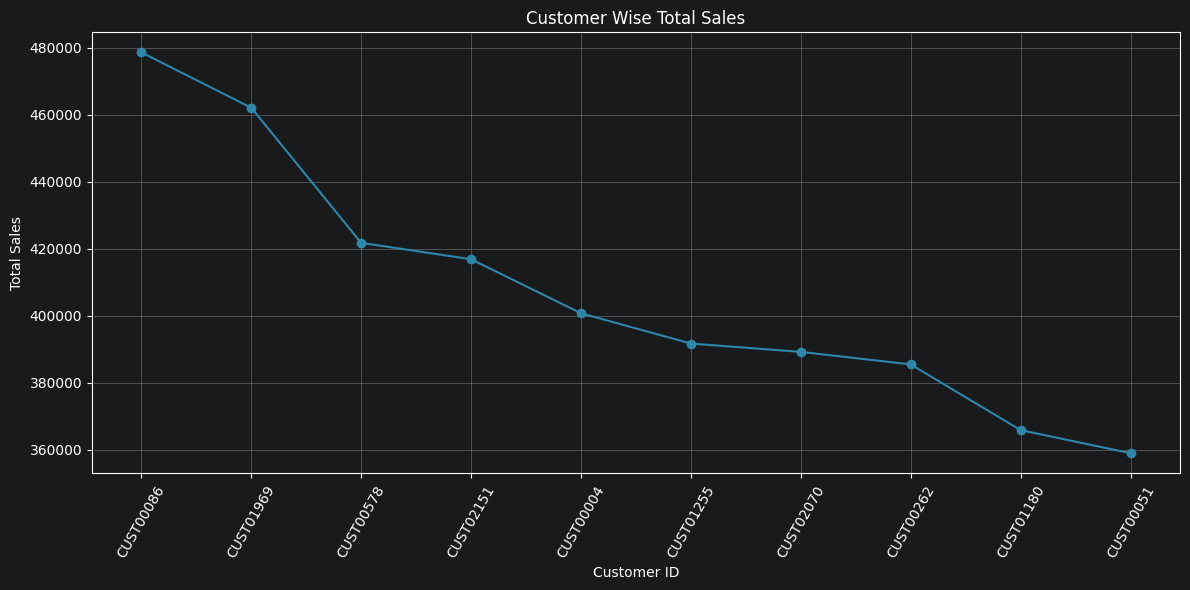

In [37]:

import pandas as pd
import matplotlib.pyplot as plt

# Customer-wise total sales
cust_sales = asn.groupby('CustomerID', as_index=False)['total_sale'].sum().sort_values('total_sale', ascending=False).head(10)

plt.figure(figsize=(12,6))
plt.plot(cust_sales['CustomerID'],cust_sales['total_sale'],marker='o',color='#2E86AB')
plt.xlabel('Customer ID')
plt.ylabel('Total Sales')
plt.title('Customer Wise Total Sales')
plt.xticks(rotation=60)
plt.grid(True)
plt.tight_layout()

plt.show()



# Month Wise Total Sales

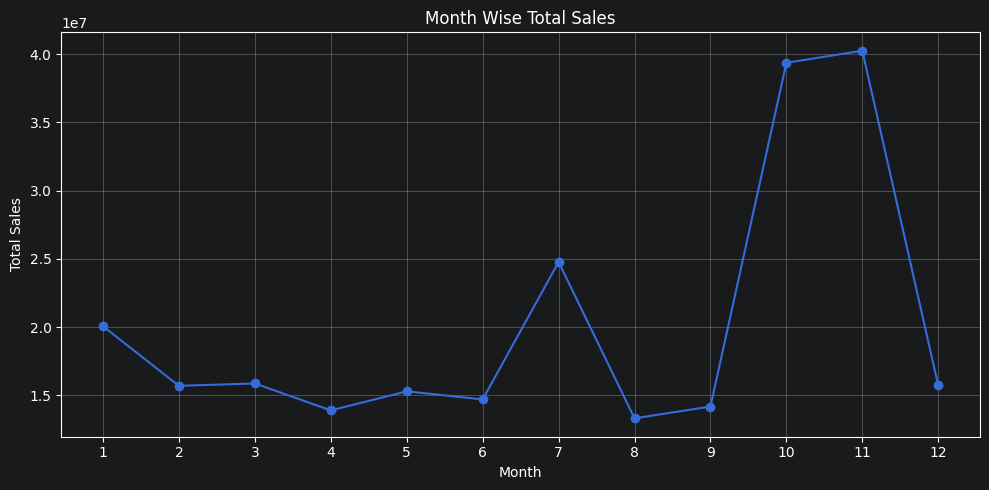

In [38]:
import matplotlib.pyplot as plt

cust_sale = (asn.groupby(['month'])['total_sale'].sum().reset_index().sort_values('month'))
plt.figure(figsize=(10,5))
plt.plot(cust_sale['month'],cust_sale['total_sale'],marker='o')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.title('Month Wise Total Sales')
plt.xticks(cust_sale['month'])
plt.grid(True)
plt.tight_layout()
plt.show()

# Age wise Total

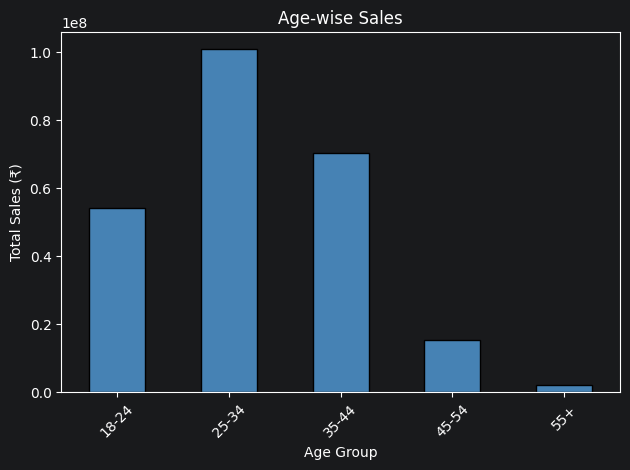

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

asn['age_group'] = pd.cut(asn['Age'], bins=[17, 24, 34, 44, 54, 100],labels=['18-24', '25-34', '35-44', '45-54', '55+'])
age_sales = asn.groupby('age_group')['total_sale'].sum()

# Bar chart
age_sales.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Age-wise Sales')
plt.xlabel('Age Group')
plt.ylabel('Total Sales (₹)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


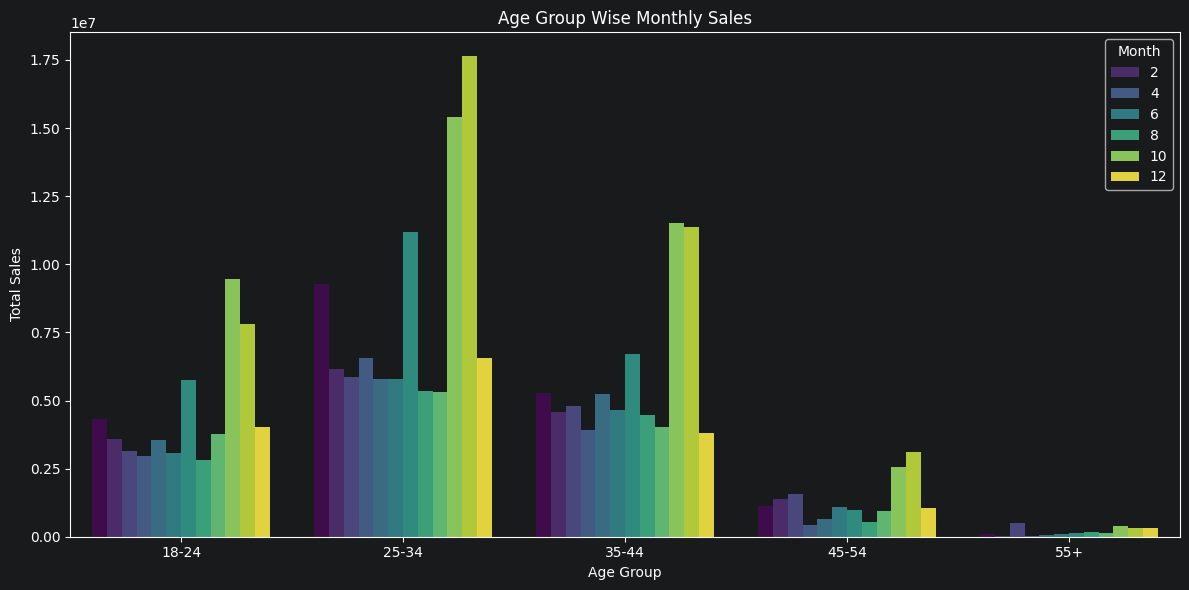

In [40]:

asn['age_group'] = pd.cut(asn['Age'],bins=[17, 24, 34, 44, 54, 100],labels=['18-24', '25-34', '35-44', '45-54', '55+'])
age_month_sales = (asn.groupby(['age_group', 'month'], as_index=False)['total_sale'].sum())

plt.figure(figsize=(12,6))

sns.barplot(data=age_month_sales,x='age_group',y='total_sale',hue='month',palette='viridis')

plt.xlabel('Age Group')
plt.ylabel('Total Sales')
plt.title('Age Group Wise Monthly Sales')

plt.legend(title='Month')
plt.tight_layout()
plt.show()

In [41]:
city_sales=asn.groupby(['City','State'])['total_sale'].sum().sort_index(ascending=False)
city_sales

City        State         
Surat       Gujarat           14936409.0
Pune        Maharashtra       17147865.0
Patna       Bihar             14691874.6
Mumbai      Maharashtra       15631326.2
Lucknow     Uttar Pradesh     15268488.0
Kolkata     West Bengal       14022300.4
Jaipur      Rajasthan         17628646.2
Indore      Madhya Pradesh    17389107.0
Hyderabad   Telangana         16681228.4
Delhi       Delhi             17541980.8
Chennai     Tamil Nadu        17613112.8
Chandigarh  Punjab            16196644.8
Bhopal      Madhya Pradesh    17067591.0
Bangalore   Karnataka         15564669.4
Ahmedabad   Gujarat           15776040.2
Name: total_sale, dtype: float64

In [42]:
sales=asn.groupby(['City']).agg(
    total_sale=('total_sale','sum'),
    maximum_sale=('total_sale','max'),
    minimum_sale=('total_sale','min'),
    avg_sale=('total_sale','mean')).reset_index()
print(sales.head())

         City  total_sale  maximum_sale  minimum_sale      avg_sale
0   Ahmedabad  15776040.2      157645.6           0.0  26033.069637
1   Bangalore  15564669.4      159724.8           0.0  26928.493772
2      Bhopal  17067591.0      158024.8           0.0  28928.120339
3  Chandigarh  16196644.8      159848.8           0.0  27175.578523
4     Chennai  17613112.8      159090.4           0.0  28873.955410


# city wise product sales

C:\Users\Udayan Care\AppData\Local\Temp\ipykernel_5164\2239919734.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=city_product,x='total_sale',y='City',palette='viridis')


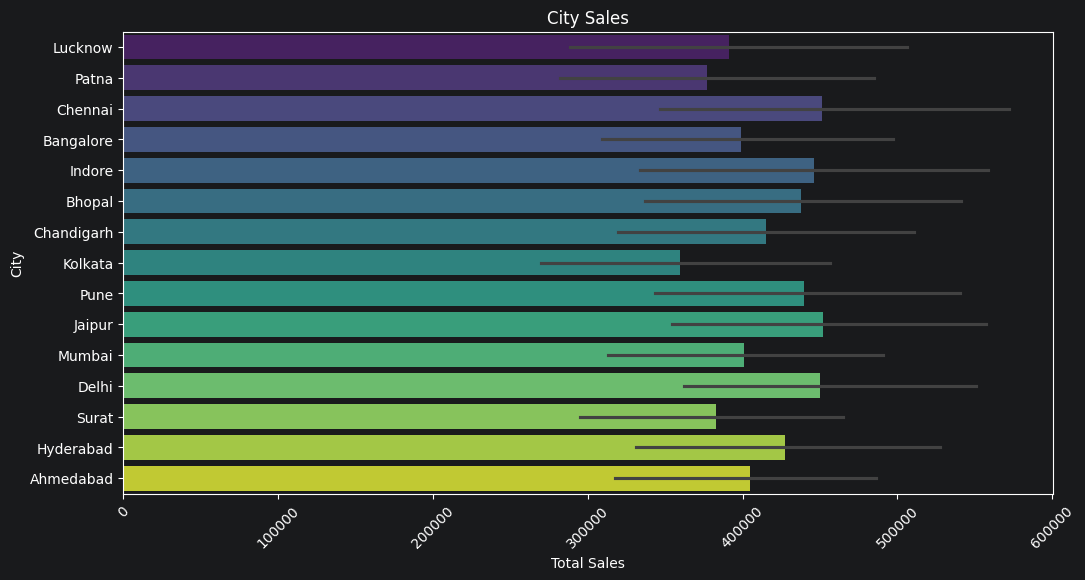

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt
city_product = (asn.groupby(['City', 'Product'], as_index=False)['total_sale'].sum().sort_values('total_sale', ascending=False))
plt.figure(figsize=(12,6))
sns.barplot(data=city_product,x='total_sale',y='City',palette='viridis')
plt.xticks(rotation=45)
plt.title('City Sales')
plt.ylabel('City')
plt.xlabel('Total Sales')
plt.show()

# city wise Category comper

<Axes: xlabel='City'>

<Figure size 1200x600 with 0 Axes>

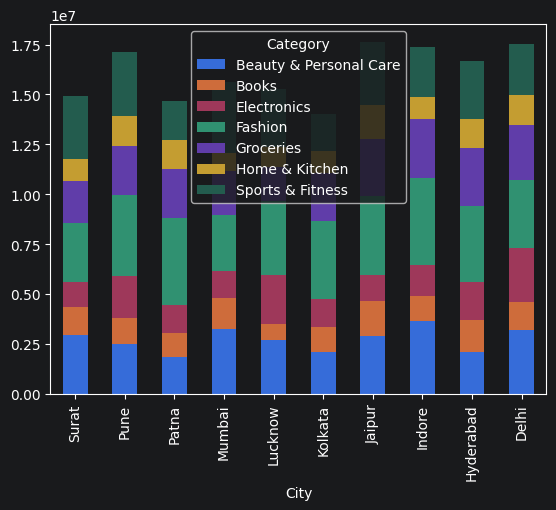

In [44]:
stacked=asn.pivot_table(values='total_sale',index='City',columns='Category',aggfunc='sum').sort_index(ascending=False).head(10)
plt.figure(figsize=(12,6))
stacked.plot(kind='bar',stacked=True)

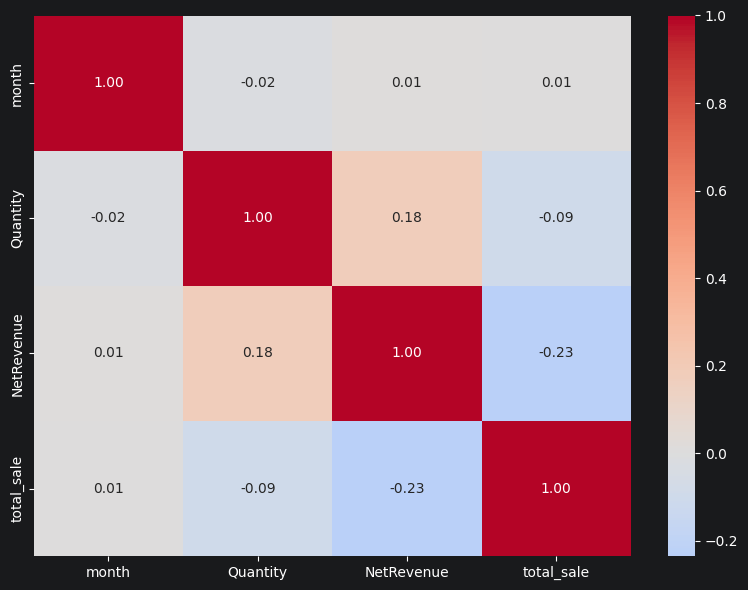

In [45]:
numeric_cols=['month','Quantity','NetRevenue','total_sale']
corr = asn[numeric_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.tight_layout()
plt.show()

In [46]:
asn.columns

Index(['OrderID', 'OrderDate', 'CustomerID', 'Gender', 'Age', 'City', 'State',
       'Category', 'Product', 'Quantity', 'UnitPrice', 'DiscountPercent',
       'ShippingCost', 'NetRevenue', 'PaymentMethod', 'OrderStatus', 'Rating',
       'total_sale', 'new_date', 'month', 'year', 'day', 'age_group'],
      dtype='str')

## Top 10 state sales

C:\Users\Udayan Care\AppData\Local\Temp\ipykernel_5164\2276266448.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state,x='State',y='total_sale',palette='viridis')


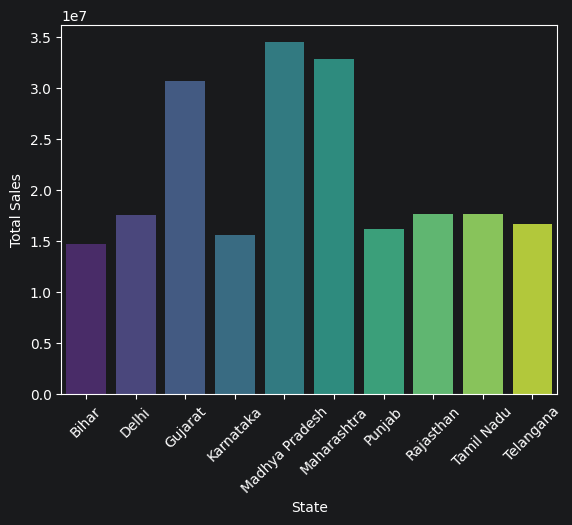

In [55]:
state=asn.groupby('State')['total_sale'].sum().reset_index().head(10)
sns.barplot(data=state,x='State',y='total_sale',palette='viridis')
plt.xlabel('State')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()